In [19]:
# from google.colab import drive
# drive.mount('/content/drive')

In [20]:
# import os
# import torch
# os.environ['TORCH'] = torch.__version__
# print(torch.__version__)

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, SubsetRandomSampler
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, log_loss, normalized_mutual_info_score
from munkres import Munkres
import random

In [22]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.cuda.manual_seed_all(42)

In [23]:
fa_feature_path = "/home/snu/Downloads/Histogram_CN_FA_20bin_updated.npy"
Histogram_feature_CN_FA_array = np.load(fa_feature_path, allow_pickle=True)

# Load MCI features
fa_feature_path = "/home/snu/Downloads/Histogram_MCI_FA_20bin_updated.npy"
Histogram_feature_MCI_FA_array = np.load(fa_feature_path, allow_pickle=True)

# Combine features and labels
X = np.vstack([Histogram_feature_CN_FA_array, Histogram_feature_MCI_FA_array])
y = np.hstack([
    np.zeros(Histogram_feature_CN_FA_array.shape[0], dtype=np.int64),
    np.ones(Histogram_feature_MCI_FA_array.shape[0], dtype=np.int64)
])
np.random.seed(42)
perm = np.random.permutation(X.shape[0])
X = X[perm]
y = y[perm]
num_nodes, num_feats = X.shape
print(f"Features: {X.shape}, Labels: {y.shape}")

Features: (300, 180), Labels: (300,)


In [24]:
class PairDataset(Dataset):
    def __init__(self, pairs, labels):
        self.pairs = pairs
        self.labels = labels

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        return self.pairs[idx][0], self.pairs[idx][1], self.labels[idx]

In [25]:
class SiameseNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=256):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)

    def forward_once(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

    def forward(self, x1, x2):
        out1 = self.forward_once(x1)
        out2 = self.forward_once(x2)
        dist = F.pairwise_distance(out1, out2)
        return dist, out1, out2

In [26]:
class OrthoLinear(nn.Module):
    """Layer that enforces orthogonality constraint using Cholesky factorization"""
    def __init__(self, in_dim, out_dim, eps=1e-4):
        super().__init__()
        self.fc = nn.Linear(in_dim, out_dim)
        self.eps = eps

    def forward(self, x):
        Y_tilde = self.fc(x)  # shape (batch_size, out_dim)
        # Compute Y_tilde^T Y_tilde (out_dim x out_dim)
        gram = Y_tilde.T @ Y_tilde + self.eps * torch.eye(Y_tilde.shape[1], device=x.device)
        # Cholesky factorization
        L = torch.linalg.cholesky(gram)
        # Inverse of L
        L_inv = torch.inverse(L)
        # Orthogonalized output
        Y = Y_tilde @ L_inv.T
        return Y

In [27]:
class SpectralNet(nn.Module):
    def __init__(self, input_dim, n_clusters, hidden_dim=256):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.ortho = OrthoLinear(hidden_dim, n_clusters)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.ortho(x)

In [28]:
def contrastive_loss(distance, label, margin=1.0):
    pos = label * torch.pow(distance, 2)
    neg = (1 - label) * torch.pow(torch.clamp(margin - distance, min=0.0), 2)
    return torch.mean(pos + neg)

In [29]:
def spectral_loss(Y, W):
    # Y: (n_samples, n_clusters)
    # W: (n_samples, n_samples)
    D = torch.diag(W.sum(axis=1))
    L = D - W
    # numerator: trace(Y^T L Y)
    num = torch.trace(Y.T @ L @ Y)
    denom = torch.trace(Y.T @ D @ Y)
    return num / (denom + 1e-12)

In [30]:
def compute_affinity(X, scale, n_neighbors=20):
    nbrs = NearestNeighbors(n_neighbors=n_neighbors + 1).fit(X)
    distances, indices = nbrs.kneighbors(X)
    distances, indices = distances[:, 1:], indices[:, 1:]
    W = np.zeros((len(X), len(X)))
    for i in range(len(X)):
        for j in range(n_neighbors):
            W[i, indices[i, j]] = np.exp(-distances[i, j] ** 2 / (2 * scale ** 2))
            W[indices[i, j], i] = W[i, indices[i, j]]
    return W

def compute_scale(X, n_neighbors=20):
    nbrs = NearestNeighbors(n_neighbors=n_neighbors + 1).fit(X)
    distances, _ = nbrs.kneighbors(X)
    return np.median(distances[:, -1])

In [31]:
def calculate_accuracy(y_pred, y_true, n_clusters):
    cm = confusion_matrix(y_true, y_pred)
    cost = np.zeros((n_clusters, n_clusters))
    for i in range(n_clusters):
        for j in range(n_clusters):
            cost[i, j] = cm[:, j].sum() - cm[i, j]
    m = Munkres()
    mapping = m.compute(cost.tolist())
    new_labels = np.zeros_like(y_pred)
    for row, col in mapping:
        new_labels[y_pred == row] = col
    return (new_labels == y_true).mean()

In [32]:
def train_siamese(siamese_net, dataloader, epochs=50, lr=1e-3, device='cpu'):
    siamese_net.to(device)
    opt = optim.Adam(siamese_net.parameters(), lr=lr)
    for ep in range(epochs):
        siamese_net.train()
        total_loss = 0.0
        for x1, x2, labels in dataloader:
            x1 = x1.to(device).float()
            x2 = x2.to(device).float()
            labels = labels.to(device).float()
            dist, _, _ = siamese_net(x1, x2)
            loss = contrastive_loss(dist, labels)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total_loss += loss.item() * x1.size(0)
        avg_loss = total_loss / len(dataloader.dataset)
        print(f"[Siamese] Epoch {ep + 1}/{epochs}, Avg Loss={avg_loss:.6f}")
    siamese_net.to('cpu')
    return siamese_net

def train_spectral(spectral_net, X_train, W, epochs=50, lr=1e-3, tol=1e-6, device='cpu'):
    spectral_net.to(device)
    opt = optim.Adam([
        {'params': spectral_net.fc1.parameters()},
        {'params': spectral_net.fc2.parameters()},
        {'params': spectral_net.ortho.fc.parameters()}
    ], lr=lr)

    X_tensor = torch.tensor(X_train, dtype=torch.float32, device=device)
    W_tensor = torch.tensor(W, dtype=torch.float32, device=device)

    prev_loss = float('inf')
    for ep in range(epochs):
        spectral_net.train()
        Y = spectral_net(X_tensor)  # (n_samples, n_clusters)
        loss = spectral_loss(Y, W_tensor)
        opt.zero_grad()
        loss.backward()
        opt.step()

        loss_item = loss.item()
        print(f"[SpectralNet] Epoch {ep + 1}/{epochs}, Loss={loss_item:.8f}")

        if abs(prev_loss - loss_item) < tol:
            print("SpectralNet converged (tol reached).")
            break
        prev_loss = loss_item
    spectral_net.to('cpu')
    return spectral_net

In [33]:
def main():
    n_clusters = 2
    hidden_dim = 256
    batch_size = 32
    n_neighbors = 20

    pairs, labels = [], []
    nbrs = NearestNeighbors(n_neighbors=n_neighbors + 1).fit(X)
    distances, indices = nbrs.kneighbors(X)

    for i in range(len(X)):
        for j in indices[i, 1:]:  # positive pairs (neighbors)
            pairs.append([X[i], X[j]])
            labels.append(1)
        all_indices = set(range(len(X)))
        neighbor_set = set(indices[i, 1:])
        non_neighbors = list(all_indices - neighbor_set - {i})
        j = np.random.choice(non_neighbors)
        pairs.append([X[i], X[j]])
        labels.append(0)

    dataset = PairDataset(pairs, labels)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Train Siamese Network
    siamese = SiameseNet(num_feats, hidden_dim)
    siamese = train_siamese(siamese, dataloader, epochs=50)

    # Embed data with Siamese
    with torch.no_grad():
        X_embed = siamese.forward_once(torch.tensor(X, dtype=torch.float32)).numpy()


    # Compute scale and affinity matrix for SpectralNet
    scale = compute_scale(X_embed, n_neighbors=n_neighbors)
    W = compute_affinity(X_embed, scale, n_neighbors=n_neighbors)
    num_edges = np.count_nonzero(W) // 2
    print("Number of edges in the graph:", num_edges)

    # Train SpectralNet
    spectral = SpectralNet(num_feats, n_clusters, hidden_dim)
    spectral = train_spectral(spectral, X, W, epochs=50)

    # Get embeddings and predictions
    with torch.no_grad():
        Y = spectral(torch.tensor(X, dtype=torch.float32)).numpy()
        y_pred_proba = F.softmax(torch.tensor(Y), dim=1).numpy()

    # KMeans clustering on SpectralNet outputs
    kmeans = KMeans(n_clusters=n_clusters, n_init=20)
    y_pred = kmeans.fit_predict(Y)

    # Evaluate accuracy with Hungarian mapping
    acc_score = calculate_accuracy(y_pred, y, n_clusters)
    acc_score_inverted = calculate_accuracy(1 - y_pred, y, n_clusters)
    if acc_score_inverted > acc_score:
        acc_score = acc_score_inverted
        y_pred = 1 - y_pred

    print(y_pred)
    prec_score = precision_score(y, y_pred)
    rec_score = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    log_loss_value = log_loss(y, y_pred_proba)
    nmi_score = normalized_mutual_info_score(y, y_pred)

    print("Final clustering accuracy:", acc_score)
    print("Precision:", prec_score)
    print("Recall:", rec_score)
    print("F1 Score:", f1)
    print("Log Loss:", log_loss_value)
    print("NMI Score:", nmi_score)

    results = {"accuracy": acc_score, "precision": prec_score, "recall": rec_score, "f1": f1, "log_loss": log_loss_value, "nmi": nmi_score}
    return results, y_pred, spectral

In [34]:
Y = spectral(torch.tensor(X, dtype=torch.float32)).detach().numpy()

NameError: name 'spectral' is not defined

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# -------- PCA on SpectralNet embeddings --------
pca = PCA(n_components=2)
Z = pca.fit_transform(Y)

# -------- PLOT --------
plt.figure(figsize=(6,5))
plt.scatter(Z[:,0], Z[:,1], c=y_pred, cmap='coolwarm', s=30)

plt.title("SpectralNet Embedding Space")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label="Cluster")

plt.tight_layout()
plt.show()

In [ ]:
from collections import Counter

print("\n===== COMMUNITY LEVEL ANALYSIS (SpectralNet) =====\n")
y_pred_spectral = y_pred

for k in range(2):
    idx = (y_pred == k)
    print(f"Cluster {k} distribution:", Counter(y[idx]))

In [ ]:
num_rois = 9
bins_per_roi = 20

roi_names = [
    "Corpus Callosum (5)",
    "Fornix (7)",
    "Corticospinal (8)",
    "Cerebral Peduncle (16)",
    "Internal Capsule (18)",
    "Cingulum (36)",
    "Cingulum (37)",
    "Cingulum (38)",
    "Cingulum (39)",
]

roi_indices = {
    roi_names[i]: (i * bins_per_roi, (i + 1) * bins_per_roi)
    for i in range(num_rois)
}

bin_edges = np.linspace(0, 1, bins_per_roi + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

In [ ]:
roi_stats = {}

for roi, (start, end) in roi_indices.items():
    roi_stats[roi] = []

    for k in range(2):
        idx = (y_pred == k)
        roi_hist = X[idx, start:end]

        weighted_mean = (roi_hist * bin_centers).sum(axis=1)
        roi_stats[roi].append(weighted_mean.mean())

In [ ]:
roi = "Cingulum (36)"
start, end = roi_indices[roi]

c0 = (X[y_pred==0, start:end] * bin_centers).sum(axis=1).mean()
c1 = (X[y_pred==1, start:end] * bin_centers).sum(axis=1).mean()

if c0 < c1:  # flip so Cluster 0 = CN
    y_pred = 1 - y_pred

In [ ]:
print("\nROI Comparison (Cluster 0 vs Cluster 1):\n")

for roi in roi_names:
    c0 = roi_stats[roi][0]
    c1 = roi_stats[roi][1]
    diff = abs(c0 - c1)

    print(f"{roi}: Cluster0={c0:.4f}, Cluster1={c1:.4f}, Diff={diff:.4f}")

In [ ]:
roi_importance = sorted(
    [(roi, abs(vals[0] - vals[1])) for roi, vals in roi_stats.items()],
    key=lambda x: x[1],
    reverse=True
)

print("\nMost Important ROIs:\n")
for roi, diff in roi_importance:
    print(f"{roi}: {diff:.4f}")

In [ ]:
print("\nStatistical Significance:\n")

for roi, (start, end) in roi_indices.items():

    c0_hist = X[y_pred == 0, start:end]
    c1_hist = X[y_pred == 1, start:end]

    c0_vals = (c0_hist * bin_centers).sum(axis=1)
    c1_vals = (c1_hist * bin_centers).sum(axis=1)

    stat, p = ttest_ind(c0_vals, c1_vals)

    print(f"{roi}: p-value = {p:.5f}")

In [ ]:
color_c0 = "#4C72B0"
color_c1 = "#DD8452"

plt.figure(figsize=(12,6))

positions = []
data = []
colors = []

gap = 1.5
width = 0.5

for i, (roi, (start,end)) in enumerate(roi_indices.items()):
    c0 = (X[y_pred==0, start:end]*bin_centers).sum(axis=1)
    c1 = (X[y_pred==1, start:end]*bin_centers).sum(axis=1)

    pos0 = i*gap
    pos1 = i*gap + width

    positions += [pos0, pos1]
    data += [c0, c1]
    colors += [color_c0, color_c1]

box = plt.boxplot(data, positions=positions, widths=0.4, patch_artist=True)

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

xticks = [i*gap + width/2 for i in range(len(roi_names))]
plt.xticks(xticks, roi_names, rotation=45)

plt.ylabel("FA Value")
plt.title("SpectralNet FA Distribution")

plt.legend(
    handles=[
        plt.Rectangle((0,0),1,1,color=color_c0),
        plt.Rectangle((0,0),1,1,color=color_c1)
    ],
    labels=["Cluster 0","Cluster 1"]
)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
if __name__ == "__main__":
    num_runs = 10
    all_results = {"accuracy": [], "precision": [], "recall": [], "f1": [], "log_loss": []}

    global final_y_pred
    final_y_pred = None

    for run in range(num_runs):
        print(f"\n--- Run {run+1}/{num_runs} ---")
        torch.manual_seed(run)
        np.random.seed(run)
        random.seed(run)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(run)

        results, y_pred_current_run = main()

        all_results["accuracy"].append(results["accuracy"])
        all_results["precision"].append(results["precision"])
        all_results["recall"].append(results["recall"])
        all_results["f1"].append(results["f1"])
        all_results["log_loss"].append(results["log_loss"])

        final_y_pred = y_pred_current_run


    print("\n================ FINAL SUMMARY ================\n")
    print(f"{'Metric':>12} | {'Mean':>10} \u00b1 {'Std':<10}")
    print("-" * 40)
    for metric, values in all_results.items():
        print(f"{metric:>12} | {np.mean(values):10.4f} \u00b1 {np.std(values):<10.4f}")

In [ ]:
from sklearn.metrics import normalized_mutual_info_score


In [ ]:
if __name__ == "__main__":
    num_runs = 10
    all_results = {
        "accuracy":  [],
        "precision": [],
        "recall":    [],
        "f1":        [],
        "nmi":       [],
        "log_loss":  [],
    }

    global final_y_pred
    final_y_pred = None

    for run in range(num_runs):
        print(f"\n--- Run {run+1}/{num_runs} ---")
        torch.manual_seed(run)
        np.random.seed(run)
        random.seed(run)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(run)

        # *_ safely absorbs any extra return values from main()
        results, y_pred_current_run, *_ = main()

        all_results["accuracy"].append(results["accuracy"])
        all_results["precision"].append(results["precision"])
        all_results["recall"].append(results["recall"])
        all_results["f1"].append(results["f1"])
        all_results["nmi"].append(results["nmi"])
        all_results["log_loss"].append(results["log_loss"])

        final_y_pred = y_pred_current_run

    print("\n================ FINAL SUMMARY ================\n")
    print(f"{'Metric':>12} | {'Mean':>10} ± {'Std':<10}")
    print("-" * 40)
    for metric, values in all_results.items():
        print(f"{metric:>12} | {np.mean(values):10.4f} ± {np.std(values):<10.4f}")


--- Run 1/10 ---
[Siamese] Epoch 1/50, Avg Loss=0.037509
[Siamese] Epoch 2/50, Avg Loss=0.035837
[Siamese] Epoch 3/50, Avg Loss=0.035910
[Siamese] Epoch 4/50, Avg Loss=0.035489
[Siamese] Epoch 5/50, Avg Loss=0.035088
[Siamese] Epoch 6/50, Avg Loss=0.034819
[Siamese] Epoch 7/50, Avg Loss=0.034914
[Siamese] Epoch 8/50, Avg Loss=0.034731
[Siamese] Epoch 9/50, Avg Loss=0.034911
[Siamese] Epoch 10/50, Avg Loss=0.034605
[Siamese] Epoch 11/50, Avg Loss=0.034649
[Siamese] Epoch 12/50, Avg Loss=0.034439
[Siamese] Epoch 13/50, Avg Loss=0.034213
[Siamese] Epoch 14/50, Avg Loss=0.034182
[Siamese] Epoch 15/50, Avg Loss=0.034378
[Siamese] Epoch 16/50, Avg Loss=0.034283
[Siamese] Epoch 17/50, Avg Loss=0.034180
[Siamese] Epoch 18/50, Avg Loss=0.034392
[Siamese] Epoch 19/50, Avg Loss=0.034028
[Siamese] Epoch 20/50, Avg Loss=0.034107
[Siamese] Epoch 21/50, Avg Loss=0.034118
[Siamese] Epoch 22/50, Avg Loss=0.033936
[Siamese] Epoch 23/50, Avg Loss=0.033952
[Siamese] Epoch 24/50, Avg Loss=0.033910
[Siames

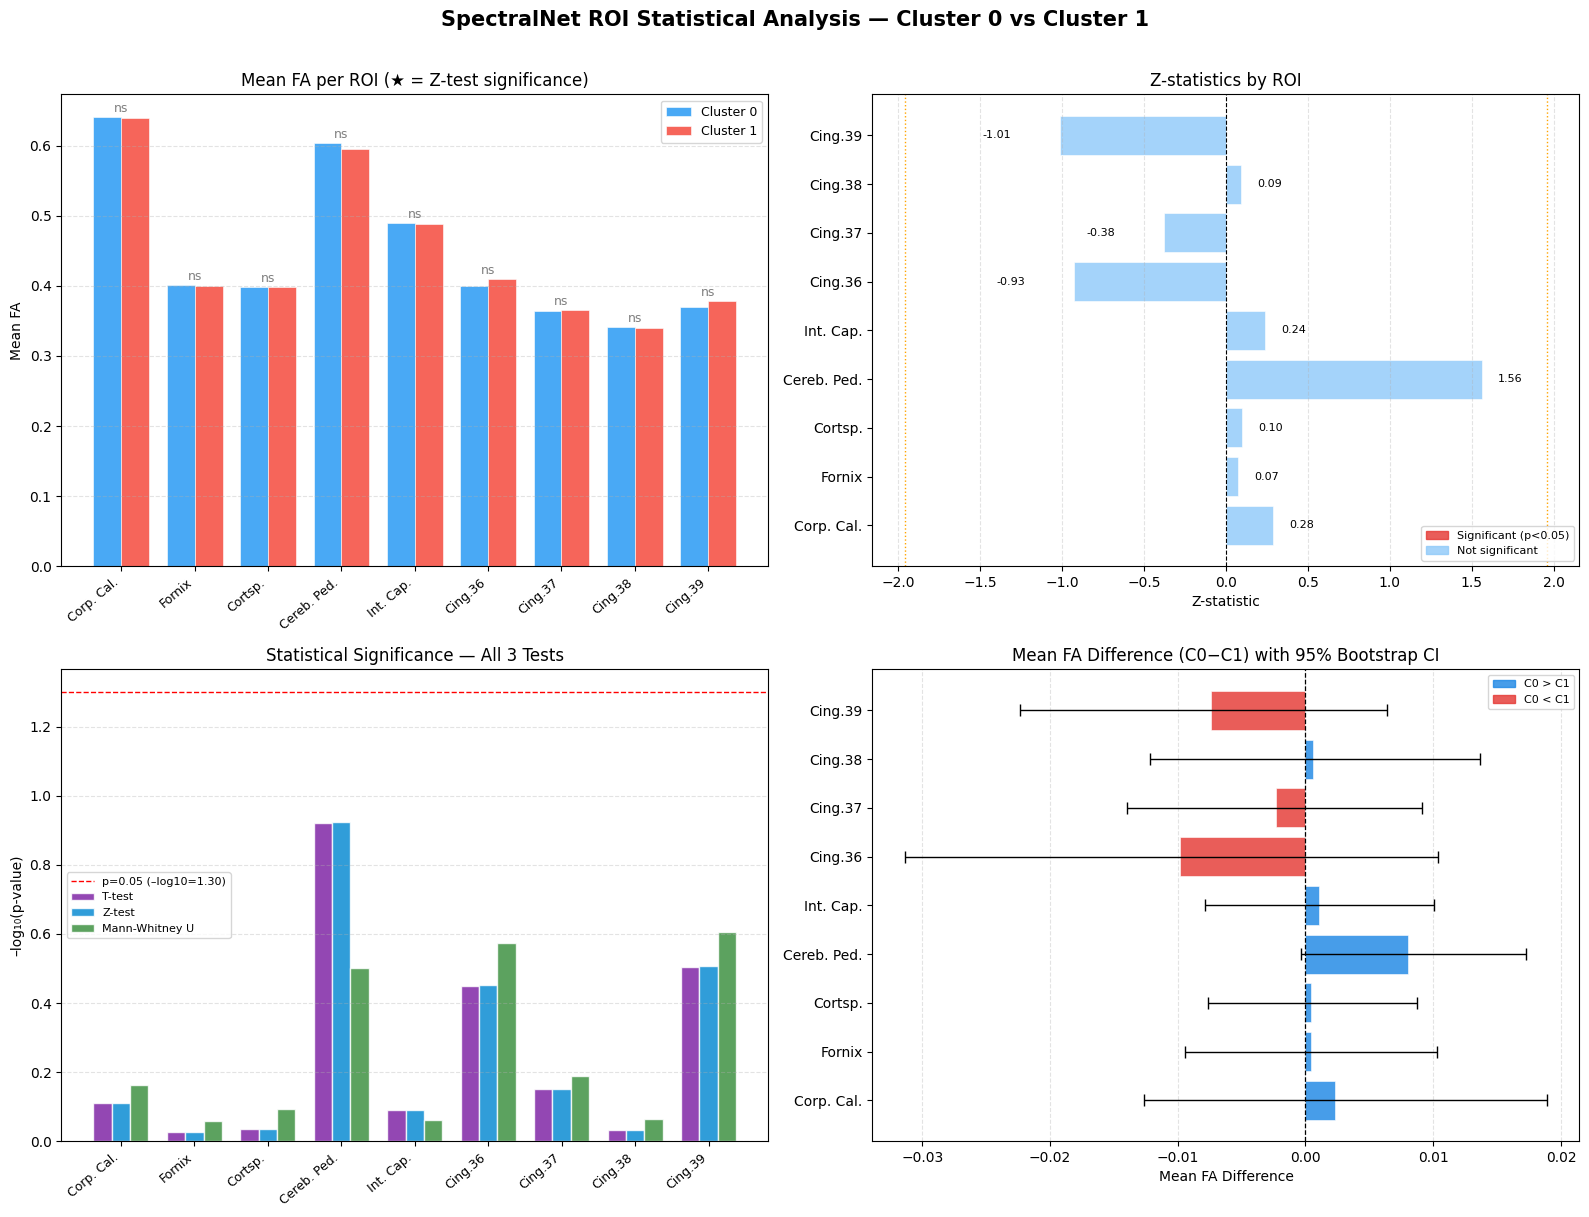

Saved: spectral_roi_combined_stats.png


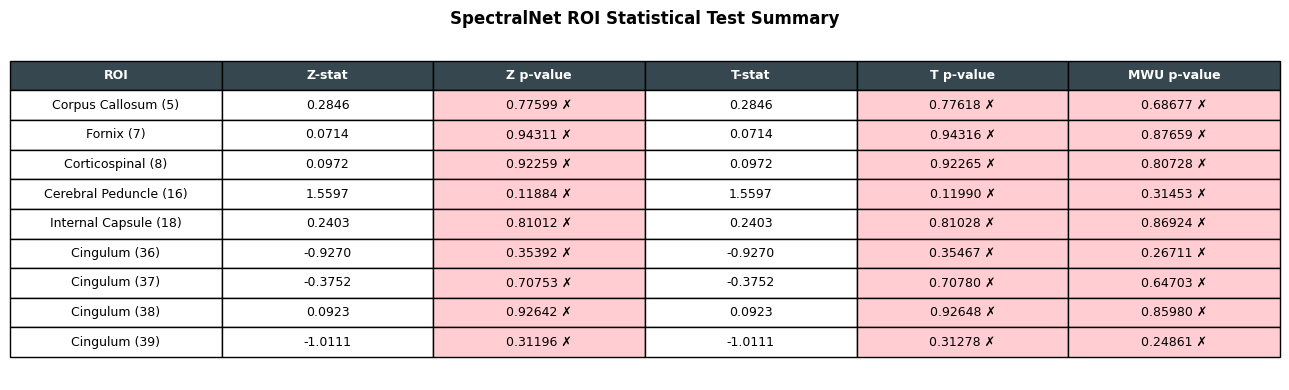

Saved: spectral_roi_pvalue_table.png


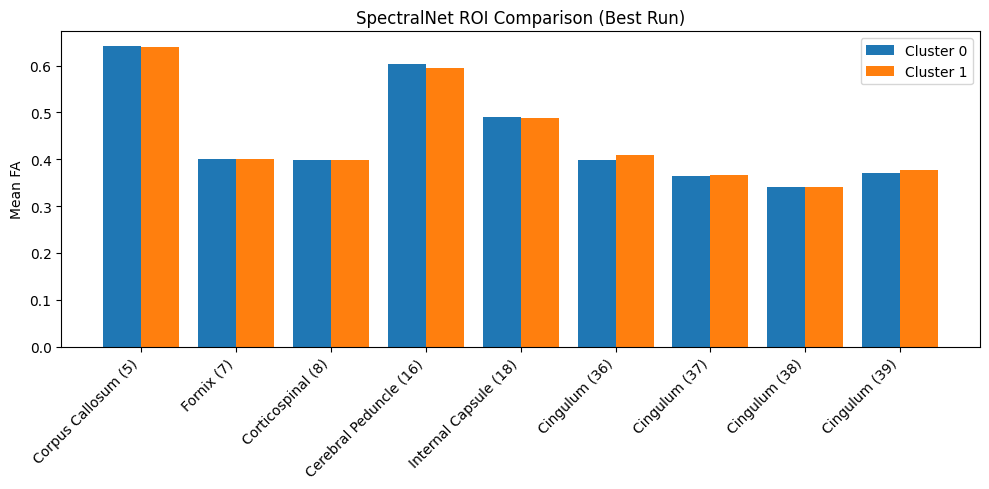

Saved: spectral_roi_barplot.png


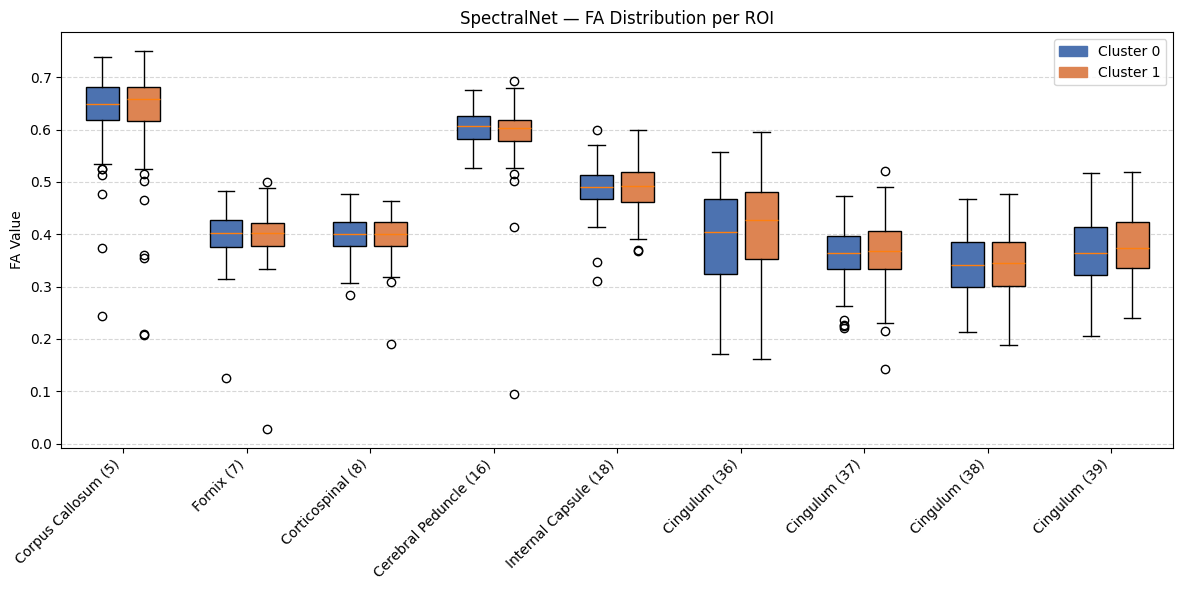

Saved: spectral_roi_boxplot.png


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import random
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, log_loss, normalized_mutual_info_score
)
from collections import Counter
from scipy.stats import ttest_ind, mannwhitneyu
from statsmodels.stats.weightstats import ztest

# ════════════════════════════════════════════════════════════════════
#  ROI CONFIG
# ════════════════════════════════════════════════════════════════════
num_rois     = 9
bins_per_roi = 20

roi_names = [
    "Corpus Callosum (5)", "Fornix (7)", "Corticospinal (8)",
    "Cerebral Peduncle (16)", "Internal Capsule (18)",
    "Cingulum (36)", "Cingulum (37)", "Cingulum (38)", "Cingulum (39)"
]
short_names = [
    "Corp. Cal.", "Fornix", "Cortsp.",
    "Cereb. Ped.", "Int. Cap.",
    "Cing.36", "Cing.37", "Cing.38", "Cing.39"
]

roi_indices = {
    roi_names[i]: (i * bins_per_roi, (i + 1) * bins_per_roi)
    for i in range(num_rois)
}

bin_edges   = np.linspace(0, 1, bins_per_roi + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# ════════════════════════════════════════════════════════════════════
#  SPECTRALNET MULTI-RUN
# ════════════════════════════════════════════════════════════════════
if __name__ == "__main__":

    num_runs    = 10
    orig_indices = np.arange(len(X))

    all_results = {
        "accuracy": [], "precision": [], "recall": [],
        "f1": [], "log_loss": [], "nmi": []
    }

    best_acc     = -1
    best_pred    = None
    best_indices = None
    best_X_run   = None
    best_y_run   = None

    for run in range(num_runs):
        print(f"\n--- Run {run+1}/{num_runs} ---")

        torch.manual_seed(run)
        np.random.seed(run)
        random.seed(run)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(run)

        perm    = np.random.permutation(len(X))
        X_run   = X[perm]
        y_run   = y[perm]
        idx_run = orig_indices[perm]

        # ── Run SpectralNet ──────────────────────────────────────
        results, y_pred_run, *_ = main() # Unpack all three return values

        acc     = results["accuracy"]
        acc_inv = accuracy_score(y_run, 1 - y_pred_run)
        if acc_inv > acc:
            y_pred_run = 1 - y_pred_run
            acc        = acc_inv

        nmi = normalized_mutual_info_score(
            y_run, y_pred_run, average_method='arithmetic'
        )

        all_results["accuracy"].append(acc)
        all_results["precision"].append(results["precision"])
        all_results["recall"].append(results["recall"])
        all_results["f1"].append(results["f1"])
        all_results["log_loss"].append(results["log_loss"])
        all_results["nmi"].append(nmi)

        print(f"Acc={acc:.4f} | F1={results['f1']:.4f} | NMI={nmi:.4f}")

        if acc > best_acc:
            best_acc     = acc
            best_pred    = y_pred_run
            best_indices = idx_run
            best_X_run   = X_run.copy()
            best_y_run   = y_run.copy()

    # ════════════════════════════════════════════════════════════════
    #  MAP PREDICTIONS BACK TO ORIGINAL ORDER
    # ════════════════════════════════════════════════════════════════
    y_pred_full = np.zeros(len(y), dtype=np.int64)
    y_pred_full[best_indices] = best_pred

    # ── Save labels ───────────────────────────────────────────────
    np.save("/home/snu/Downloads/spectral_labels.npy", y_pred_full)
    print("\nSaved: spectral_labels.npy")
    print("Shape:", y_pred_full.shape)
    print("Unique:", np.unique(y_pred_full))

    # ════════════════════════════════════════════════════════════════
    #  FINAL SUMMARY
    # ════════════════════════════════════════════════════════════════
    print("\n================ FINAL SUMMARY ================\n")
    print(f"{'Metric':>12} | {'Mean':>10} \u00b1 {'Std':<10}")
    print("-" * 40)
    for metric, values in all_results.items():
        print(f"{metric:>12} | {np.mean(values):10.4f} \u00b1 {np.std(values):<10.4f}")

    # ════════════════════════════════════════════════════════════════
    #  COMMUNITY ANALYSIS  (best run, mapped-back order)
    # ════════════════════════════════════════════════════════════════
    print("\n===== COMMUNITY LEVEL ANALYSIS (SpectralNet) =====\n")
    for k in range(2):
        print(f"Cluster {k}:", Counter(y[y_pred_full == k]))

    # ════════════════════════════════════════════════════════════════
    #  COMPUTE ALL STATS  (T-test, Z-test, Mann-Whitney U)
    #  NOTE: uses best_X_run / best_pred (permuted best run)
    # ════════════════════════════════════════════════════════════════
    roi_stats = {}
    for roi, (start, end) in roi_indices.items():
        vals = []
        for k in range(2):
            roi_hist = best_X_run[best_pred == k, start:end]
            weighted = (roi_hist * bin_centers).sum(axis=1)
            vals.append(weighted.mean())
        roi_stats[roi] = vals

    records = []
    for roi, (start, end) in roi_indices.items():
        c0_vals = (best_X_run[best_pred == 0, start:end] * bin_centers).sum(axis=1)
        c1_vals = (best_X_run[best_pred == 1, start:end] * bin_centers).sum(axis=1)

        mean_c0 = c0_vals.mean()
        mean_c1 = c1_vals.mean()
        diff    = mean_c0 - mean_c1

        t_stat, t_pval = ttest_ind(c0_vals, c1_vals)
        z_stat, z_pval = ztest(c0_vals, c1_vals, value=0)
        u_stat, u_pval = mannwhitneyu(c0_vals, c1_vals, alternative='two-sided')

        records.append({
            "ROI":     roi,
            "Mean_C0": round(mean_c0, 4),
            "Mean_C1": round(mean_c1, 4),
            "Diff":    round(diff, 4),
            "T_stat":  round(t_stat, 4),
            "T_pval":  round(t_pval, 6),
            "T_sig":   t_pval < 0.05,
            "Z_stat":  round(z_stat, 4),
            "Z_pval":  round(z_pval, 6),
            "Z_sig":   z_pval < 0.05,
            "U_stat":  round(u_stat, 4),
            "U_pval":  round(u_pval, 6),
            "U_sig":   u_pval < 0.05,
        })

    df = pd.DataFrame(records)

    # ── Save CSV ──────────────────────────────────────────────────
    df.to_csv("/home/snu/Downloads/spectral_roi_stats.csv", index=False)
    print("\nSaved: spectral_roi_stats.csv")
    print(df.to_string(index=False))

    # ── Print tables ──────────────────────────────────────────────
    print("\nStatistical Significance (T-test):\n")
    print(f"{'ROI':<30} | {'T-stat':>10} | {'P-value':>10} | {'Significant':>12}")
    print("-" * 70)
    for _, row in df.iterrows():
        sig = "Yes \u2713" if row["T_sig"] else "No"
        print(f"{row['ROI']:<30} | {row['T_stat']:>10.4f} | "
              f"{row['T_pval']:>10.5f} | {sig:>12}")

    print("\nStatistical Significance (2-Sample Z-test):\n")
    print(f"{'ROI':<30} | {'Z-stat':>10} | {'P-value':>10} | {'Significant':>12}")
    print("-" * 70)
    for _, row in df.iterrows():
        sig = "Yes \u2713" if row["Z_sig"] else "No"
        print(f"{row['ROI']:<30} | {row['Z_stat']:>10.4f} | "
              f"{row['Z_pval']:>10.5f} | {sig:>12}")

    # ════════════════════════════════════════════════════════════════
    #  COMBINED 4-PANEL FIGURE
    # ════════════════════════════════════════════════════════════════
    x     = np.arange(len(roi_names))
    width = 0.38
    alpha = 0.82

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(
        "SpectralNet ROI Statistical Analysis \u2014 Cluster 0 vs Cluster 1",
        fontsize=15, fontweight='bold', y=1.01
    )

    # ── Panel 1 : Mean FA bar chart ──────────────
    ax = axes[0, 0]
    ax.bar(x - width/2, df["Mean_C0"], width, label="Cluster 0",
           color="#2196F3", alpha=alpha, edgecolor='white', linewidth=0.5)
    ax.bar(x + width/2, df["Mean_C1"], width, label="Cluster 1",
           color="#F44336", alpha=alpha, edgecolor='white', linewidth=0.5)

    for i, row in df.iterrows():
        stars = ("***" if row["Z_pval"] < 0.001 else
                 "**"  if row["Z_pval"] < 0.01  else
                 "*"   if row["Z_pval"] < 0.05  else "ns")
        ymax  = max(row["Mean_C0"], row["Mean_C1"]) + 0.003
        ax.text(i, ymax, stars, ha='center', va='bottom', fontsize=9,
                color='black' if stars != "ns" else 'gray')

    ax.set_xticks(x)
    ax.set_xticklabels(short_names, rotation=40, ha='right', fontsize=9)
    ax.set_ylabel("Mean FA")
    ax.set_title("Mean FA per ROI (\u2605 = Z-test significance)")
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.35)

    # ── Panel 2 : Z-statistics ──────────────
    ax       = axes[0, 1]
    colors_z = ["#E53935" if s else "#90CAF9" for s in df["Z_sig"]]
    bars     = ax.barh(short_names, df["Z_stat"], color=colors_z,
                       edgecolor='white', linewidth=0.5, alpha=alpha)
    ax.axvline(0,     color='black',  linewidth=0.8, linestyle='--')
    ax.axvline(-1.96, color='orange', linewidth=1,   linestyle=':',
               label='\u00b11.96 threshold')
    ax.axvline( 1.96, color='orange', linewidth=1,   linestyle=':')

    for bar, val in zip(bars, df["Z_stat"]):
        ax.text(val - 0.3 if val < 0 else val + 0.1,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.2f}", va='center',
                ha='right' if val < 0 else 'left', fontsize=8)

    sig_patch   = mpatches.Patch(color='#E53935', alpha=alpha, label='Significant (p<0.05)')
    unsig_patch = mpatches.Patch(color='#90CAF9', alpha=alpha, label='Not significant')
    ax.legend(handles=[sig_patch, unsig_patch], fontsize=8, loc='lower right')
    ax.set_title("Z-statistics by ROI")
    ax.set_xlabel("Z-statistic")
    ax.grid(axis='x', linestyle='--', alpha=0.35)

    # ── Panel 3 : –log10(p-value) all 3 tests ─────────────
    ax    = axes[1, 0]
    log_t = -np.log10(df["T_pval"].clip(lower=1e-300))
    log_z = -np.log10(df["Z_pval"].clip(lower=1e-300))
    log_u = -np.log10(df["U_pval"].clip(lower=1e-300))
    w3    = 0.25

    ax.bar(x - w3, log_t, w3, label="T-test",
           color="#7B1FA2", alpha=alpha, edgecolor='white')
    ax.bar(x,      log_z, w3, label="Z-test",
           color="#0288D1", alpha=alpha, edgecolor='white')
    ax.bar(x + w3, log_u, w3, label="Mann-Whitney U",
           color="#388E3C", alpha=alpha, edgecolor='white')

    threshold_line = -np.log10(0.05)
    ax.axhline(threshold_line, color='red', linestyle='--', linewidth=1,
               label=f'p=0.05 (\u2013log10={threshold_line:.2f})')

    ax.set_xticks(x)
    ax.set_xticklabels(short_names, rotation=40, ha='right', fontsize=9)
    ax.set_ylabel("\u2013log\u2081\u2080(p-value)")
    ax.set_title("Statistical Significance \u2014 All 3 Tests")
    ax.legend(fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.35)

    # ── Panel 4 : Signed mean diff + bootstrap CI ───────────────
    ax = axes[1, 1]
    np.random.seed(42)
    ci_low, ci_high = [], []
    for roi, (start, end) in roi_indices.items():
        c0v = (best_X_run[best_pred == 0, start:end] * bin_centers).sum(axis=1)
        c1v = (best_X_run[best_pred == 1, start:end] * bin_centers).sum(axis=1)
        boot_diffs = [
            np.random.choice(c0v, len(c0v), replace=True).mean() -
            np.random.choice(c1v, len(c1v), replace=True).mean()
            for _ in range(1000)
        ]
        ci_low.append(np.percentile(boot_diffs, 2.5))
        ci_high.append(np.percentile(boot_diffs, 97.5))

    diffs    = df["Diff"].values
    err_low  = diffs - np.array(ci_low)
    err_high = np.array(ci_high) - diffs
    colors_d = ["#E53935" if d < 0 else "#1E88E5" for d in diffs]

    ax.barh(short_names, diffs,
            xerr=[err_low, err_high],
            color=colors_d, alpha=alpha,
            edgecolor='white', linewidth=0.5,
            error_kw=dict(ecolor='black', capsize=4, linewidth=1))
    ax.axvline(0, color='black', linewidth=0.9, linestyle='--')
    ax.set_title("Mean FA Difference (C0\u2212C1) with 95% Bootstrap CI")
    ax.set_xlabel("Mean FA Difference")
    ax.grid(axis='x', linestyle='--', alpha=0.35)

    pos_patch = mpatches.Patch(color='#1E88E5', alpha=alpha, label='C0 > C1')
    neg_patch = mpatches.Patch(color='#E53935', alpha=alpha, label='C0 < C1')
    ax.legend(handles=[pos_patch, neg_patch], fontsize=8)

    plt.tight_layout()
    plt.savefig("/home/snu/Downloads/spectral_roi_combined_stats.png",
                dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: spectral_roi_combined_stats.png")

    # ════════════════════════════════════════════════════════════════
    #  P-VALUE SUMMARY TABLE AS IMAGE
    # ════════════════════════════════════════════════════════════════
    fig2, ax2 = plt.subplots(figsize=(13, 4))
    ax2.axis('off')

    table_data = []
    for _, row in df.iterrows():
        checkmark = '\u2713'
        crossmark = '\u2717'
        def fmt(pval, sig):
            return f"{pval:.5f} {checkmark if sig else crossmark}"
        table_data.append([
            row["ROI"],
            f"{row['Z_stat']:.4f}",
            fmt(row["Z_pval"], row["Z_sig"]),
            f"{row['T_stat']:.4f}",
            fmt(row["T_pval"], row["T_sig"]),
            fmt(row["U_pval"], row["U_sig"]),
        ])

    col_labels = ["ROI", "Z-stat", "Z p-value", "T-stat", "T p-value", "MWU p-value"]
    tbl = ax2.table(
        cellText=table_data,
        colLabels=col_labels,
        loc='center',
        cellLoc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.6)

    for (row_idx, col_idx), cell in tbl.get_celld().items():
        if row_idx == 0:
            cell.set_facecolor('#37474F')
            cell.set_text_props(color='white', fontweight='bold')
        elif col_idx in [2, 4, 5]:
            txt = cell.get_text().get_text()
            cell.set_facecolor('#C8E6C9' if '\u2713' in txt else '#FFCDD2')

    ax2.set_title("SpectralNet ROI Statistical Test Summary",
                  fontsize=12, fontweight='bold', pad=10)
    plt.tight_layout()
    plt.savefig("/home/snu/Downloads/spectral_roi_pvalue_table.png",
                dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: spectral_roi_pvalue_table.png")

    # ════════════════════════════════════════════════════════════════
    #  BAR PLOT
    # ════════════════════════════════════════════════════════════════
    roi_means_c0 = [roi_stats[r][0] for r in roi_names]
    roi_means_c1 = [roi_stats[r][1] for r in roi_names]
    x_pos        = np.arange(len(roi_names))

    plt.figure(figsize=(10, 5))
    plt.bar(x_pos - 0.2, roi_means_c0, width=0.4, label="Cluster 0")
    plt.bar(x_pos + 0.2, roi_means_c1, width=0.4, label="Cluster 1")
    plt.xticks(x_pos, roi_names, rotation=45, ha='right')
    plt.ylabel("Mean FA")
    plt.title("SpectralNet ROI Comparison (Best Run)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("/home/snu/Downloads/spectral_roi_barplot.png",
                dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: spectral_roi_barplot.png")

    # ════════════════════════════════════════════════════════════════
    #  BOX PLOT
    # ════════════════════════════════════════════════════════════════
    color_c0 = "#4C72B0"
    color_c1 = "#DD8452"

    plt.figure(figsize=(12, 6))
    positions, data, colors = [], [], []
    gap, bw = 1.5, 0.5

    for i, (roi, (start, end)) in enumerate(roi_indices.items()):
        c0 = (best_X_run[best_pred == 0, start:end] * bin_centers).sum(axis=1)
        c1 = (best_X_run[best_pred == 1, start:end] * bin_centers).sum(axis=1)
        positions += [i * gap, i * gap + bw]
        data      += [c0, c1]
        colors    += [color_c0, color_c1]

    box = plt.boxplot(data, positions=positions, widths=0.4, patch_artist=True)
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)

    xticks = [i * gap + bw / 2 for i in range(len(roi_names))]
    plt.xticks(xticks, roi_names, rotation=45, ha='right')
    plt.ylabel("FA Value")
    plt.title("SpectralNet \u2014 FA Distribution per ROI")
    plt.legend(
        handles=[
            plt.Rectangle((0, 0), 1, 1, color=color_c0),
            plt.Rectangle((0, 0), 1, 1, color=color_c1)
        ],
        labels=["Cluster 0", "Cluster 1"]
    )
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig("/home/snu/Downloads/spectral_roi_boxplot.png",
                dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: spectral_roi_boxplot.png")

With 20 neighbors, with 32 batch size

      Metric |       Mean ± Std       
----------------------------------------
    accuracy |     0.6270 ± 0.0491    
   precision |     0.5165 ± 0.1315    
      recall |     0.4737 ± 0.1695    
          f1 |     0.4912 ± 0.1511    
    log_loss |     0.7008 ± 0.0080    

With 20 neighbors, with 64 batch size
      Metric |       Mean ± Std       
----------------------------------------
    accuracy |     0.6207 ± 0.0469    
   precision |     0.5173 ± 0.1251    
      recall |     0.4707 ± 0.1689    
          f1 |     0.4892 ± 0.1484    
    log_loss |     0.7009 ± 0.0070    